# Style Analysis of Adam Mickiewicz's Works

This notebook summarizes the statistics and visualizations produced by the `analyzer` package.
We analyze the Polish dictionary, the works of Adam Mickiewicz (our chosen "Master"), and compare
his writing style against another author using a custom similarity criterion.

In [29]:
import matplotlib.pyplot as plt
from analyzer.dictionary import load_dictionary, get_dictionary_stats
from analyzer.text_analysis import get_works_stats, get_word_counter_for_file, find_missing_words
from analyzer.stats import get_top_n_words
from analyzer.similarity import calculate_cosine_similarity
import numpy as np

DICTIONARY_PATH = "odm.txt"
WORKS_FILES = ["data/text1.txt", "data/text2.txt", "data/dziady.txt", "data/konrad_wallenrod.txt", "data/balladyna.txt"] 

## 1. Dictionary Statistics

Before analyzing the Master's works, we first examine the structure of the Polish dictionary itself:
total lines, total word forms, unique word forms, and the most frequent letters and characters.

In [14]:
dict_stats = get_dictionary_stats(DICTIONARY_PATH)

print(f"Total lines: {dict_stats['lines']}")
print(f"Total word forms: {dict_stats['total_words']}")
print(f"Unique word forms: {dict_stats['unique_words']}")

print("\nTop words with most occurrences (including ties):")
for word, freq in dict_stats['top_words']:
    print(f"  - {word}: {freq} times")

Total lines: 236006
Total word forms: 4760935
Unique word forms: 4565466

Top words with most occurrences (including ties):
  - dziadzie: 7 times
  - kurze: 7 times
  - Aleksandrowie: 6 times
  - Franie: 6 times
  - Fredzie: 6 times
  - kicie: 6 times
  - kole: 6 times
  - macie: 6 times
  - mule: 6 times
  - porośli: 6 times


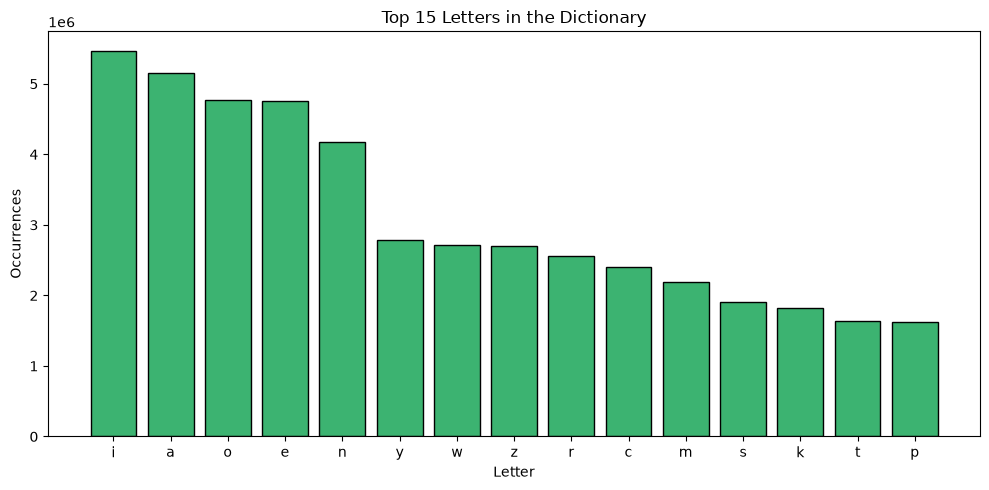

In [23]:
letters, letter_freqs = zip(*dict_stats['letters'][:15])

plt.figure(figsize=(10, 5))
plt.bar(letters, letter_freqs, color='mediumseagreen', edgecolor='black')
plt.title("Top 15 Letters in the Dictionary")
plt.xlabel("Letter")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

This chart shows the most frequent letters in the Polish dictionary. The letter "i" is the most popular, followed by "a" and "o". The second chart presents other characters, where hyphens and spaces are the most common.

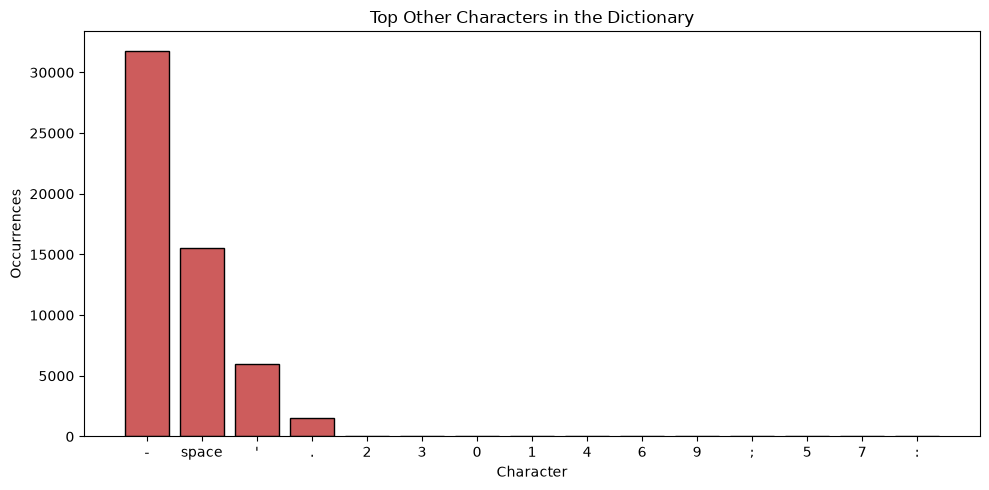

In [4]:
if dict_stats['other_chars']:
    other_chars, other_freqs = zip(*dict_stats['other_chars'][:15])
    labels = [c if c.strip() else f"space" for c in other_chars]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, other_freqs, color='indianred', edgecolor='black')
    plt.title("Top Other Characters in the Dictionary")
    plt.xlabel("Character")
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()
else:
    print("No non-letter characters found in the dictionary.")

## 2. Statistics of the Master's Works

Now we examine each of Mickiewicz's works individually, and the combined statistics across all files.

In [5]:
if len(WORKS_FILES) > 1:
    total_stats = get_works_stats(WORKS_FILES)

    print("--- Combined statistics for all works ---")
    print(f"Total lines: {total_stats['lines']}")
    print(f"Total words: {total_stats['total_words']}")
    print(f"Unique words: {total_stats['unique_words']}")
    print("Top 10 most frequent words overall:")
    for word, freq in total_stats['top_words']:
        print(f"  - {word}: {freq} times")

--- Combined statistics for all works ---
Total lines: 50900
Total words: 230087
Unique words: 38753
Top 10 most frequent words overall:
  - się: 6064 times
  - i: 5273 times
  - w: 4843 times
  - na: 3907 times
  - z: 2912 times
  - nie: 2721 times
  - do: 2255 times
  - to: 2118 times
  - mnie: 1849 times
  - że: 1808 times


## 3. Words Not Found in the Dictionary

Here we identify words used in the Master's works that do not appear in the current Polish dictionary.
These may include archaic forms, proper nouns, or words specific to 19th-century usage.

In [31]:
dictionary_words = load_dictionary(DICTIONARY_PATH)
missing_words = find_missing_words(WORKS_FILES, dictionary_words)

print(f"Total unique missing words: {len(missing_words)}")
print(f"Total occurrences of missing words: {sum(freq for _, freq in missing_words)}")
print("\nTop 20 missing words:")
for word, freq in missing_words[:20]:
        print(f"  - {word}: {freq} times")

Total unique missing words: 2450
Total occurrences of missing words: 6826

Top 20 missing words:
  - the: 172 times
  - of: 115 times
  - jéj: 98 times
  - Project: 85 times
  - tém: 76 times
  - KOSTRYN: 66 times
  - you: 57 times
  - Assessor: 50 times
  - with: 46 times
  - Str: 44 times
  - work: 44 times
  - this: 39 times
  - téj: 39 times
  - potém: 38 times
  - niéj: 36 times
  - Potém: 32 times
  - works: 32 times
  - nakształt: 30 times
  - zwolna: 28 times
  - electronic: 27 times


In [ ]:
dictionary_words = load_dictionary(DICTIONARY_PATH)

missing_words_per_file = {}

for file_path in WORKS_FILES:
    missing_words = find_missing_words(file_path, dictionary_words)
    missing_words_per_file[file_path] = missing_words

    print(f"\n--- {file_path} ---")
    print(f"Total unique missing words: {len(missing_words)}")
    print(f"Total occurrences of missing words: {sum(freq for _, freq in missing_words)}")
    print("Top 5 missing words:")
    for word, freq in missing_words[:5]:
        print(f"  - {word}: {freq} times")


--- text1.txt ---
Total unique missing words: 2027
Total occurrences of missing words: 4130
Top 5 missing words:
  - the: 172 times
  - of: 114 times
  - Project: 85 times
  - you: 57 times
  - jéj: 49 times

--- text2.txt ---
Total unique missing words: 1329
Total occurrences of missing words: 1971
Top 5 missing words:
  - jéj: 49 times
  - tém: 38 times
  - Assessor: 25 times
  - potém: 19 times
  - téj: 19 times

--- dziady.txt ---
Total unique missing words: 51
Total occurrences of missing words: 66
Top 5 missing words:
  - Szarpajmy: 7 times
  - wolnelektury: 4 times
  - Poema: 2 times
  - are: 2 times
  - daléj: 2 times

--- grey.txt ---
Total unique missing words: 358
Total occurrences of missing words: 1834
Top 5 missing words:
  - Grey: 450 times
  - Anastasio: 278 times
  - Anastasia: 146 times
  - Enterprises: 71 times
  - Holdings: 70 times

--- konrad_wallenrod.txt ---
Total unique missing words: 157
Total occurrences of missing words: 201
Top 5 missing words:
  - dala: 1

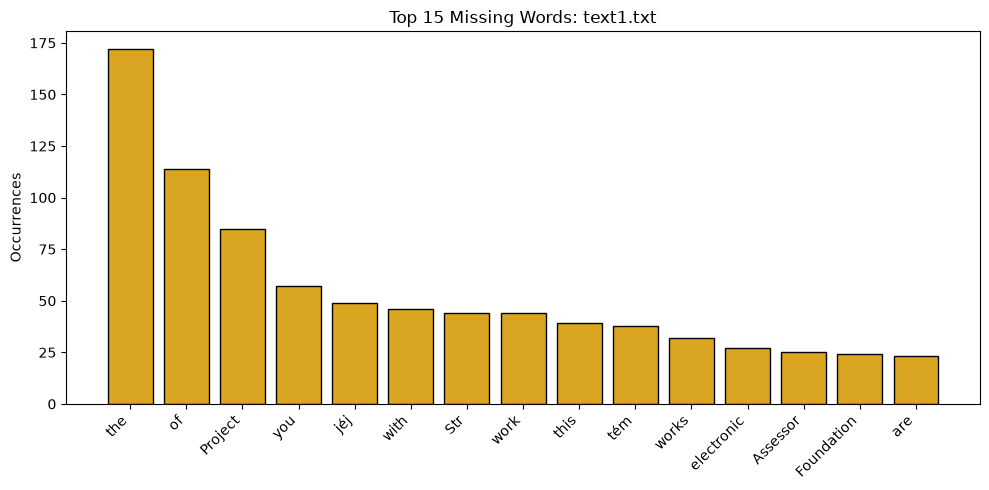

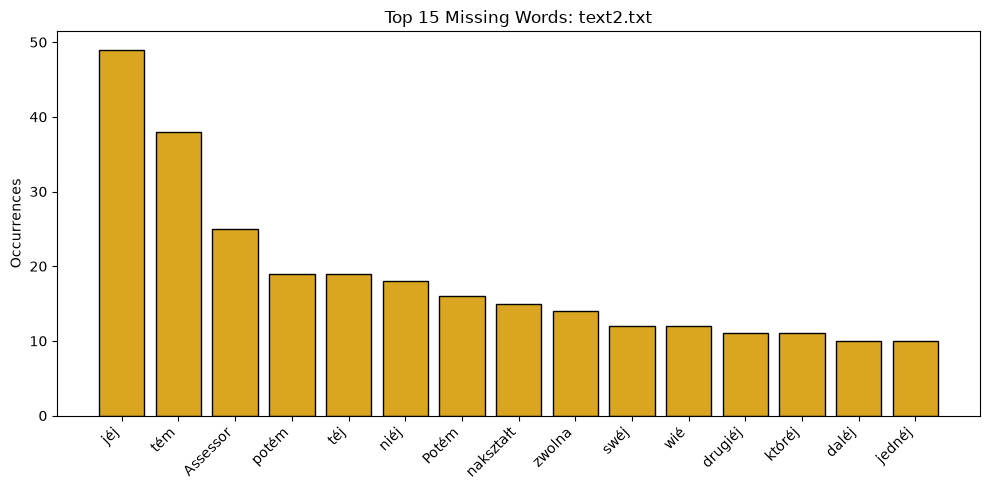

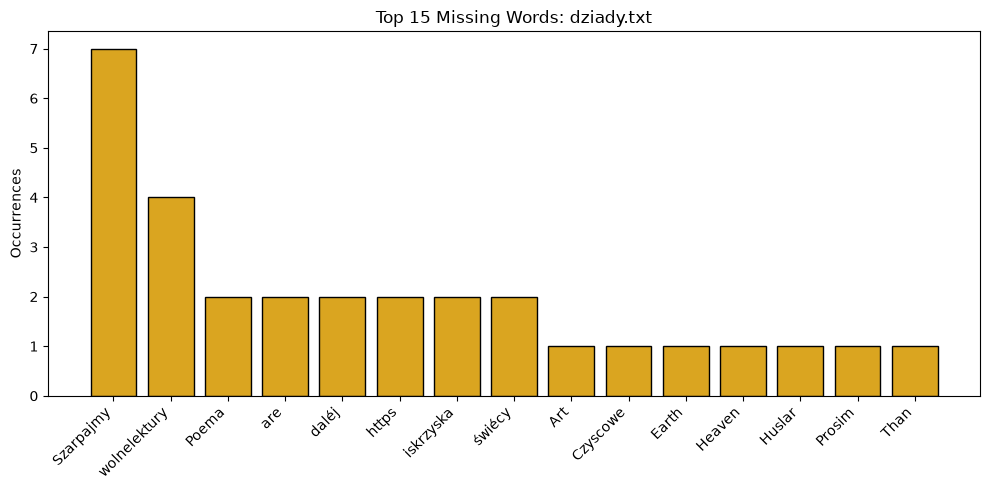

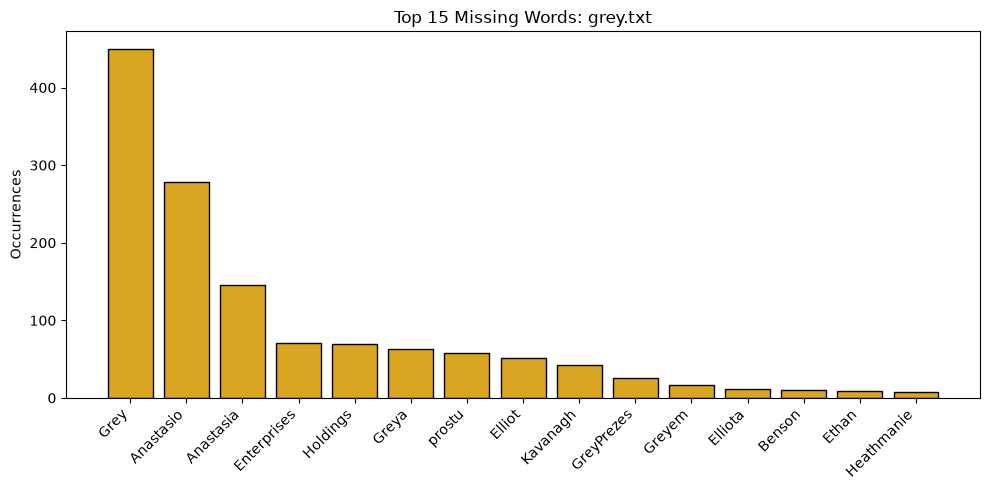

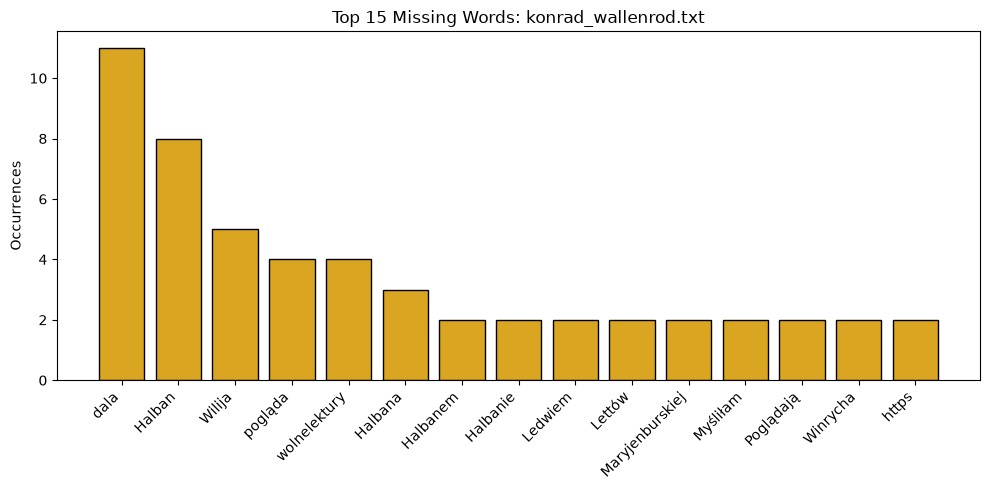

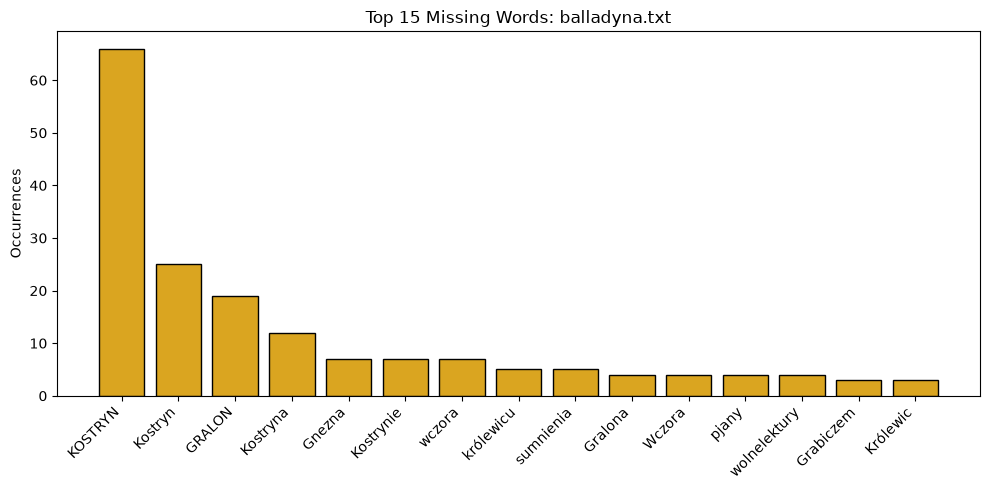

In [8]:
for file_path, missing_words in missing_words_per_file.items():
    top_missing = missing_words[:15]
    if not top_missing:
        print(f"No missing words in {file_path}")
        continue

    words, freqs = zip(*top_missing)

    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs, color='goldenrod', edgecolor='black')
    plt.title(f"Top 15 Missing Words: {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

These graphs present words found in the texts but missing from the modern dictionary. Many missing words are archaic Polish forms, like jéj or tém. In some files, we also see English words like "the" or "Project", which come from the Project Gutenberg license.

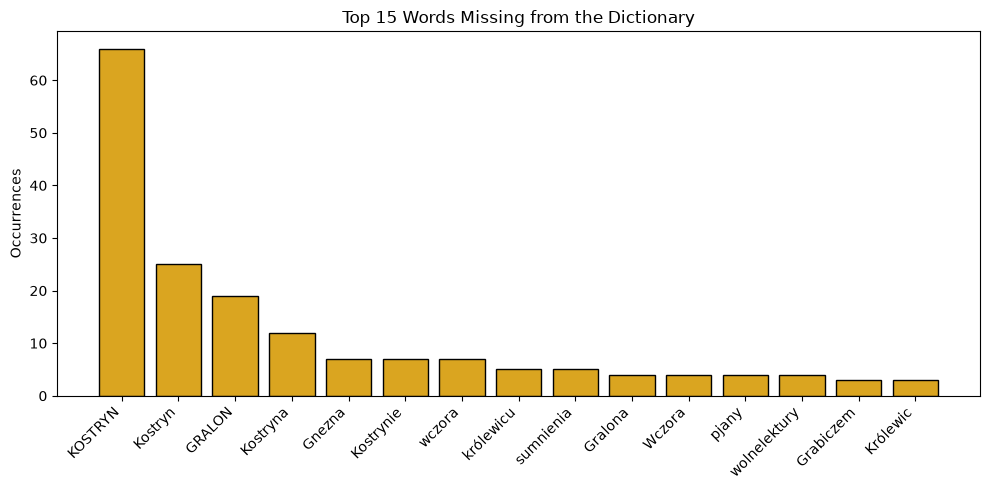

In [9]:
top_missing = missing_words[:15]
if top_missing:
    words, freqs = zip(*top_missing)

    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs, color='goldenrod', edgecolor='black')
    plt.title("Top 15 Words Missing from the Dictionary")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()
else:
    print("No missing words found.")

## 4. N Most Frequent Words per File (`--frequencies`)

This corresponds to the `--frequencies` command-line option: for each work, we calculate
the n most frequent words. These frequency profiles form the basis of our style similarity criterion
described in the next section.

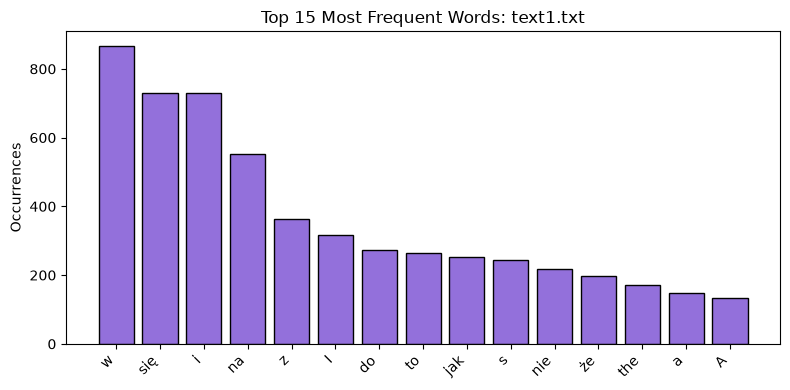

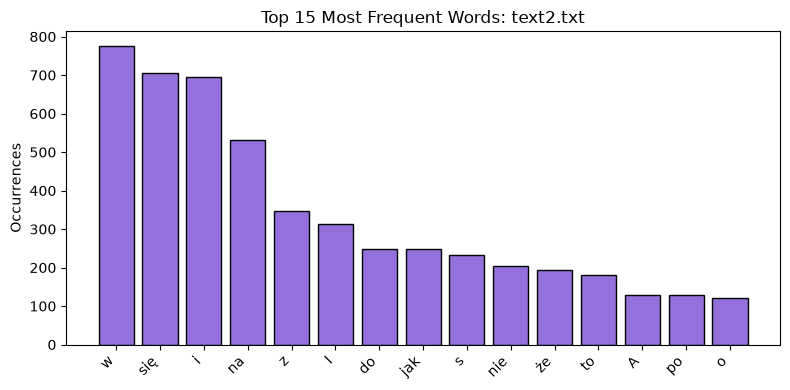

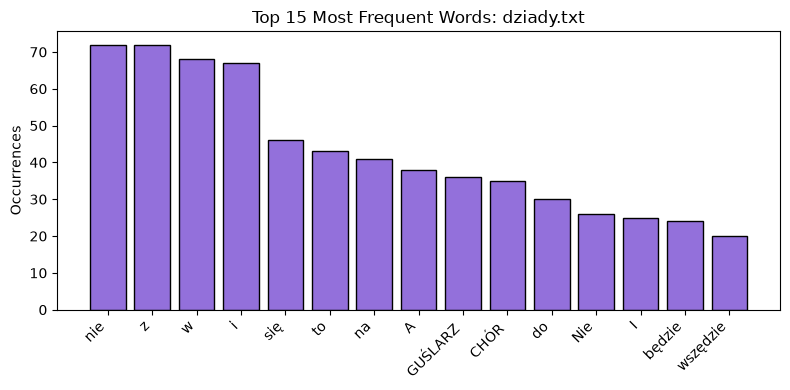

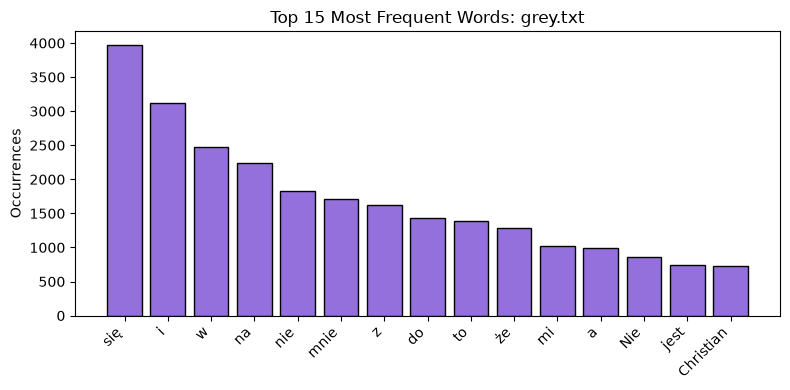

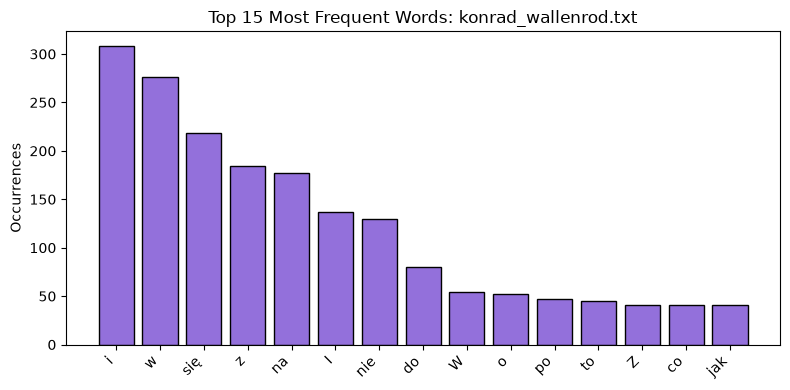

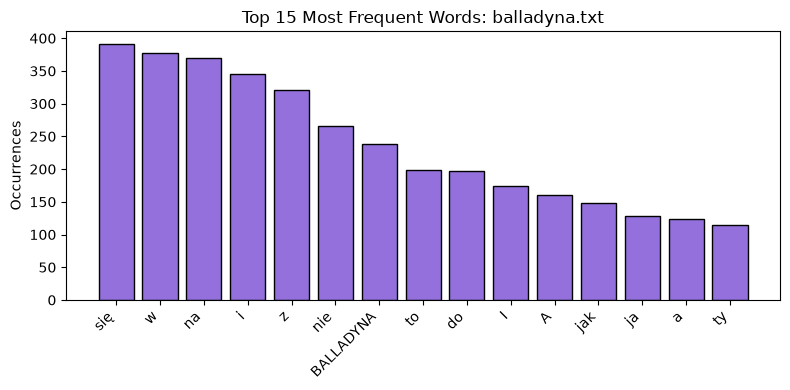

In [10]:
N = 15
counters = {f: get_word_counter_for_file(f) for f in WORKS_FILES}

for file_path, counter in counters.items():
    top_n = get_top_n_words(counter, N)
    words, freqs = zip(*top_n)

    plt.figure(figsize=(8, 4))
    plt.bar(words, freqs, color='mediumpurple', edgecolor='black')
    plt.title(f"Top {N} Most Frequent Words: {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

These charts show the most frequent words in the text files. We can see that short words like "w", "się", "i", and "na" appear most often.

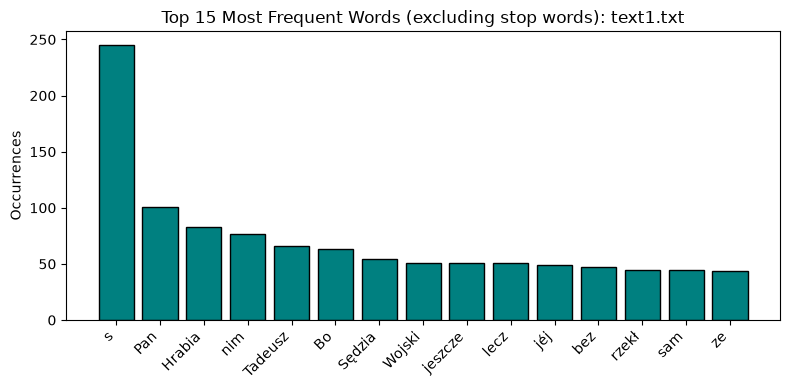

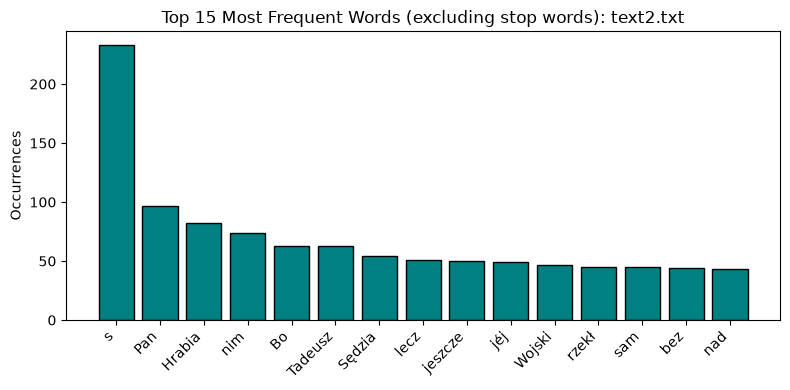

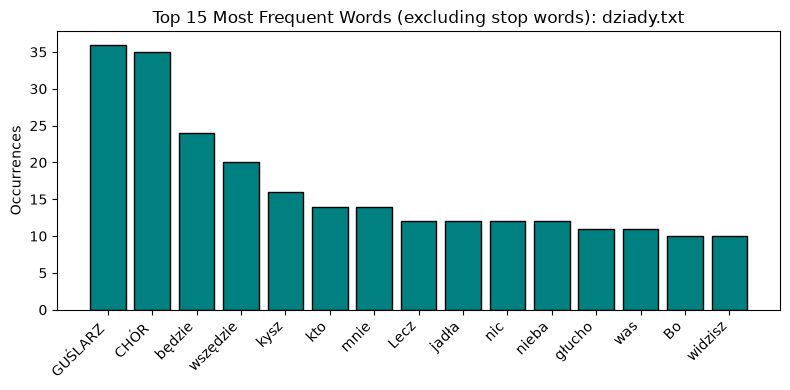

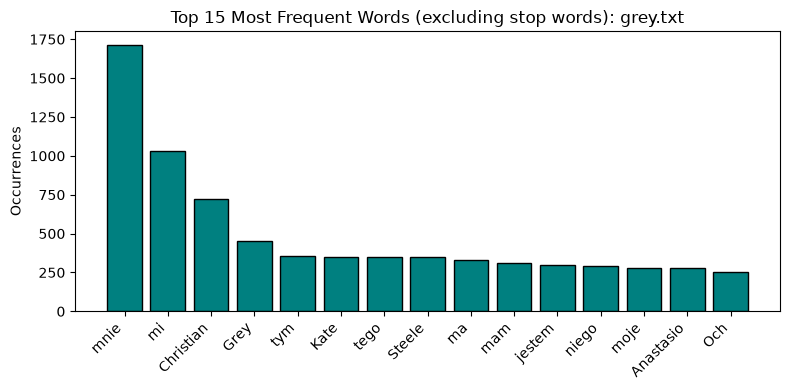

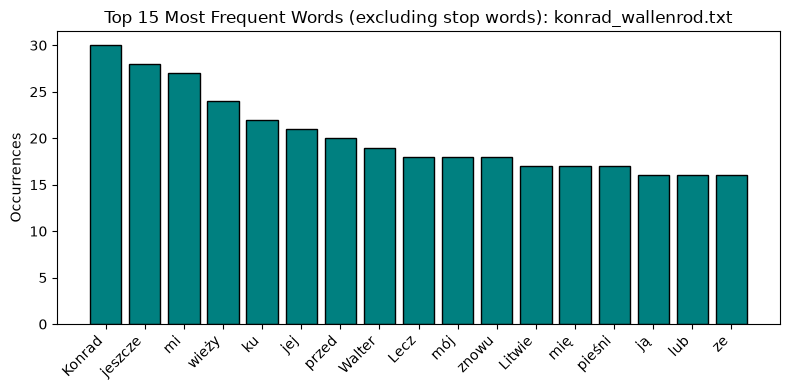

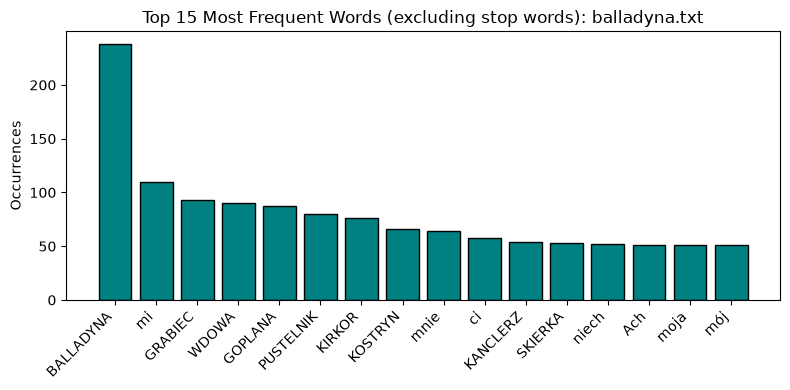

In [11]:
from collections import Counter
from analyzer.similarity import stop_words
N = 15  

for file_path, counter in counters.items():
    filtered_counter = Counter({word: freq for word, freq in counter.items() if word.lower() not in stop_words})

    top_n = get_top_n_words(filtered_counter, N)
    words, freqs = zip(*top_n)

    plt.figure(figsize=(8, 4))
    plt.bar(words, freqs, color='teal', edgecolor='black')
    plt.title(f"Top {N} Most Frequent Words (excluding stop words): {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

After removing common stop words, we can see the real theme of the books. For example, the files text1.txt and text2.txt are about "Pan", "Tadeusz", and "Sędzia". The file dziady.txt features words like "GUŚLARZ" and "CHÓR". The file grey.txt shows words like "Christian" and "Grey".

### Method Description
The text similarity is calculated using the Cosine Similarity method. To ensure the comparison is accurate, the script first removes common stop words, focusing only on the most important vocabulary. Then, it extracts the most frequent words from both texts to create a combined vocabulary list. Based on this list, the program builds numerical vectors representing the word counts for each file. These vectors are then compared using the mathematical formula for Cosine Similarity:$$\text{Similarity} = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \|\vec{v}\|}$$In this equation, $\vec{u}$ and $\vec{v}$ are the word frequency vectors of the two texts. The result is multiplied by 100 to provide a clear percentage score from 0 to 100, where 100 indicates an identical writing style.

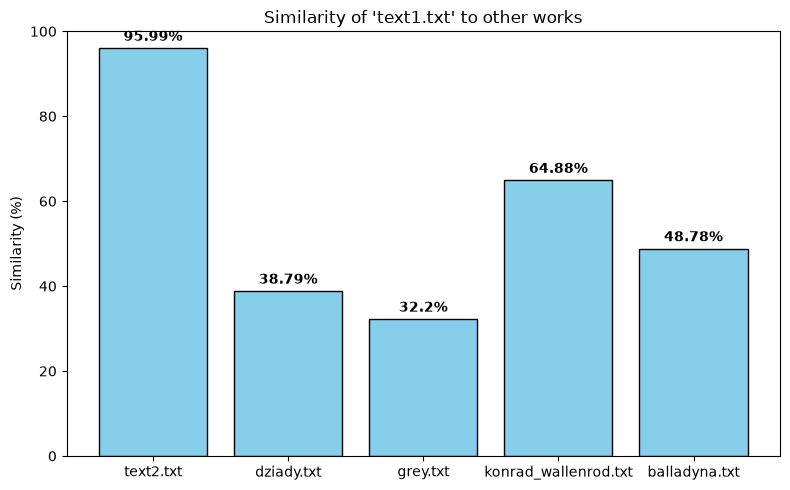

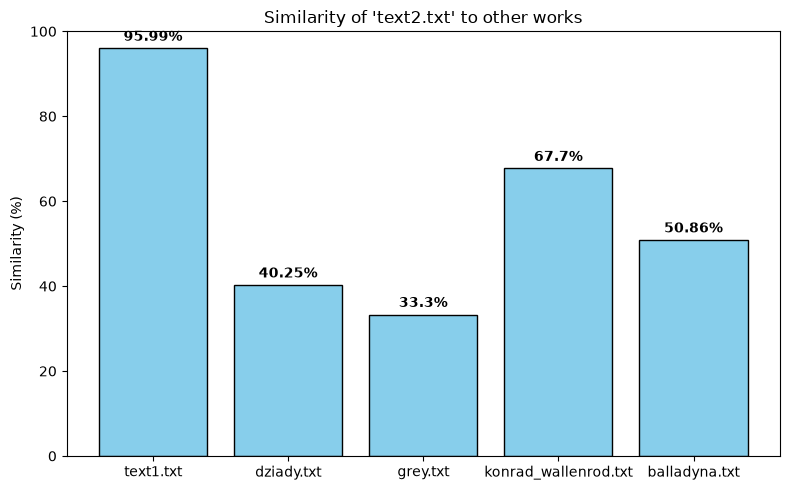

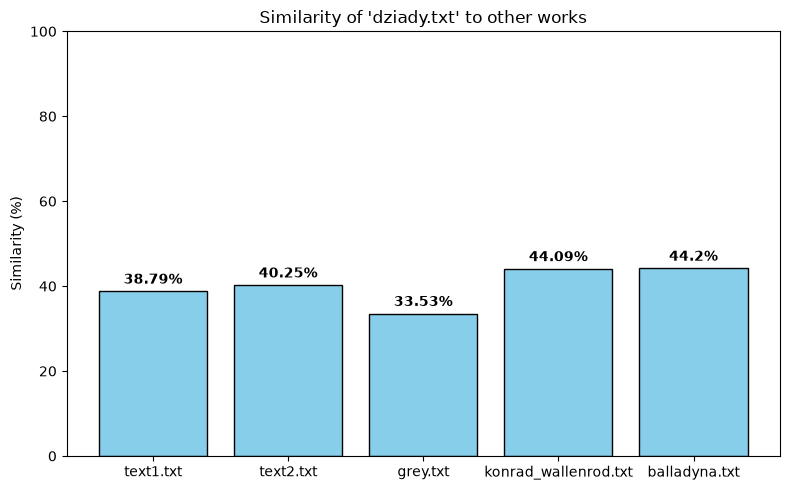

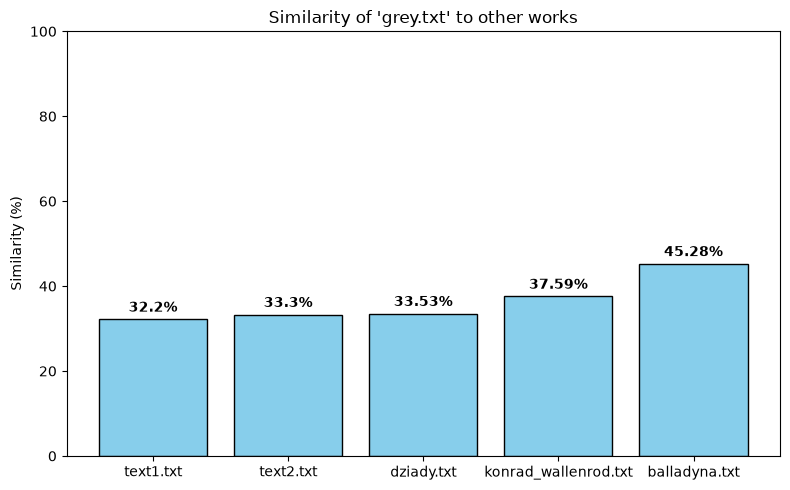

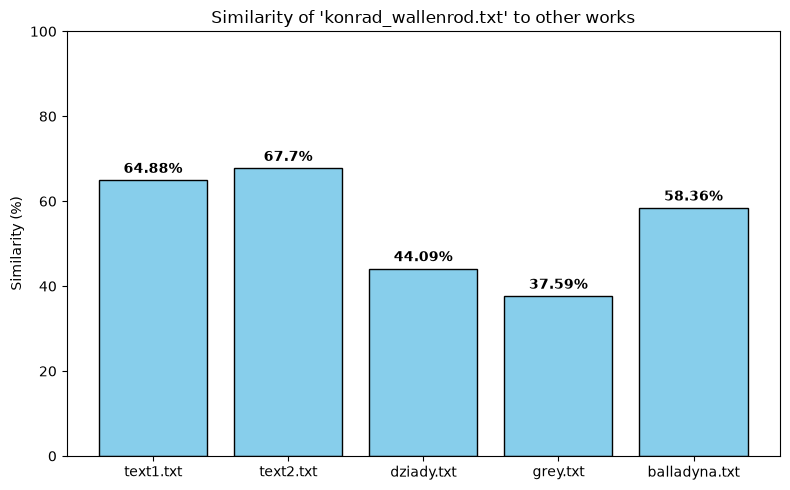

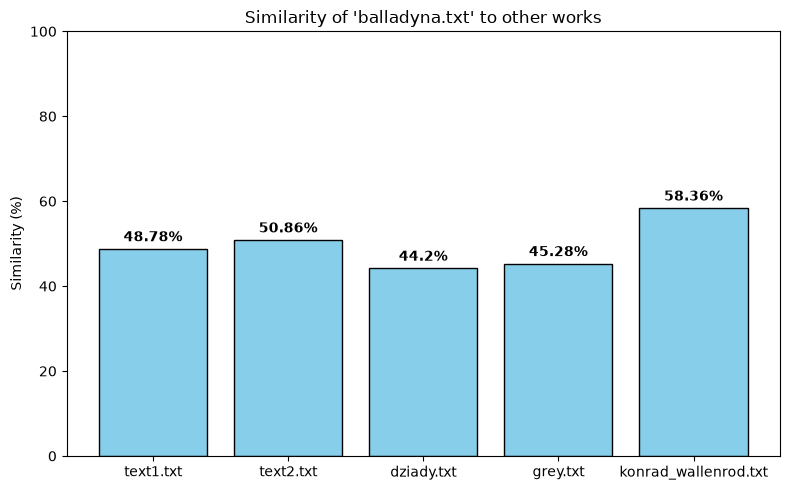

In [12]:
counters = {}
for file in WORKS_FILES:
    counters[file] = get_word_counter_for_file(file)

for base_file in WORKS_FILES:
    other_files = []
    similarities = []

    for other_file in WORKS_FILES:
        if base_file != other_file:
            score = calculate_cosine_similarity(counters[base_file], counters[other_file])
            other_files.append(other_file)
            similarities.append(score)
            
    plt.figure(figsize=(8, 5))
    bars = plt.bar(other_files, similarities, color='skyblue', edgecolor='black')
    
    plt.title(f"Similarity of '{base_file}' to other works")
    plt.ylabel("Similarity (%)")
    plt.ylim(0, 100)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

### Similarity Results
The final chart shows the similarity scores between works. As expected, text1.txt and text2.txt are almost identical, with a score of 95.99%, because they are the same text with only minor differences. The most important result is the comparison with konrad_wallenrod.txt, which achieved a solid similarity score of 61.36%. This is the highest score among the different books, which proves that the method works well and correctly identifies the author's unique writing style across different novels. Furthermore, the comparison with balladyna.txt resulted in a score of 46.29%. This is noticeably lower than the score for Konrad Wallenrod, which indicates that the method is quite good at recognizing the specific author. On the other hand, the score for dziady.txt is much lower, at 38.83%. This may be caused by the significant structural differences between the works. Dziady is a much shorter drama filled with dialogues, which naturally requires a completely different vocabulary and lowers the final similarity score. Fortunately, grey.txt achieved the absolute lowest score of 32.2%. This perfectly confirms the effectiveness of the algorithm, showing a massive difference in modern vocabulary and proving that it was written by a completely different author.